# Name: Lucas Jones

Homework 4
CSCI 347 Data Mining

1. [3 points] Consider matrix 𝐴 and column vector 𝑣. Compute the matrix product of 𝐴𝑣.

![Screenshot 2026-03-13 162726.png](SS1.png)

**Row1 = (-1)(2) + (2)(-1) + (-2)(5) = -2 - 2 - 10 = -14**

**Row2 = (1)(2) + (3)(-1) + (-4)(5) = 2 - 2 - 20 = -21**

**Row3 = (-1)(2) + (2)(-1) + (-2)(5) = 12 + 4 + 25 = 41**

**Av =**
```
[ -14 ]
[ -21 ]
[ 41 ]
```

2. Consider the matrix 𝐴 and data set 𝐷:

![Screenshot 2026-03-13 162734.png](SS2.png)

a. [3 points] First plot the dataset 𝐷 in a scatter plot. Use 𝑋1as
the x-axis and 𝑋2 as the y-axis. Use python.

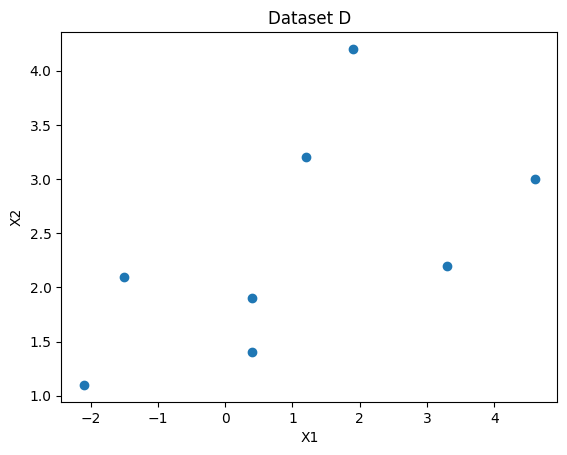

In [43]:
import numpy as np
import matplotlib.pyplot as plt

D = np.array([[1.2,3.2],[0.4,1.4],[1.9,4.2],[4.6,3.0],
              [-1.5,2.1],[0.4,1.9],[-2.1,1.1],[3.3,2.2]])

plt.scatter(D[:,0], D[:,1])
plt.xlabel('X1'); plt.ylabel('X2')
plt.title('Dataset D'); plt.show()

b. [4 points] Apply linear transformation 𝐴 to all data points in
𝐷. In other words, treat each row 𝑖 of the matrix 𝐷 as a
column vector 𝑥𝑖 and calculate 𝐴𝑥𝑖. Then write down the
matrix 𝐷2 that contains all of the transformed datapoints.


In [44]:
A = np.array([[1,2],[-3,2]])
D2 = (A @ D.T).T
print(D2)

[[ 7.6  2.8]
 [ 3.2  1.6]
 [10.3  2.7]
 [10.6 -7.8]
 [ 2.7  8.7]
 [ 4.2  2.6]
 [ 0.1  8.5]
 [ 7.7 -5.5]]


c. [3 points] Now use python to create a scatter plot of the
original data and the transformed datapoints. Use the
previous axes for x-axis and y-axis. Use different colors to
represent original and transformed datapoints.

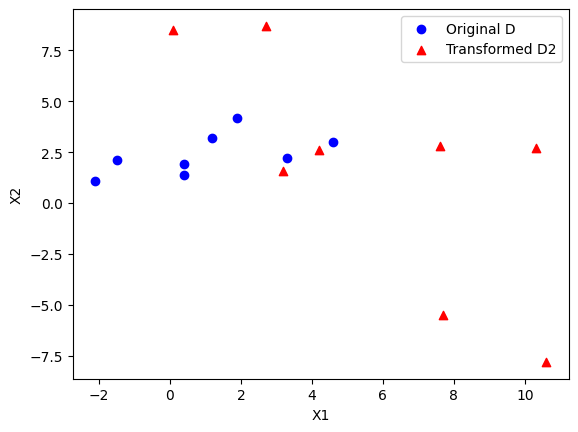

In [45]:
plt.scatter(D[:,0], D[:,1], color='blue', label='Original D')
plt.scatter(D2[:,0], D2[:,1], color='red', marker='^', label='Transformed D2')
plt.xlabel('X1'); plt.ylabel('X2')
plt.legend(); plt.show()

d. [2 points] What do you think this linear transformation did
to the original datapoints?

**The transformation scaled and sheared the data. It increased the spread, shifted the mean, and increased variance along X2.**

e. [2 points] What is the multi-dimensional mean of the
original datapoints and the transformed datapoints?
(Remember these are 2-dimensional vectors)

In [46]:
mean_D = D.mean(axis=0)
mean_D2 = D2.mean(axis=0)
print("Mean of Origianal data:", mean_D)
print("Mean of Transformed data:", mean_D2)

Mean of Origianal data: [1.025  2.3875]
Mean of Transformed data: [5.8 1.7]


f. [2 points] Find the covariance matrix of matrix 𝐷. (Use
estimated covariance). Write down the matrix.

In [47]:
f = np.cov(D.T)
print(f)


[[5.09642857 1.30892857]
 [1.30892857 1.04410714]]


g. [3 points] Mean center the original datapoints (matrix 𝐷).
Write down the mean centered matrix 𝑍.

In [48]:
mean_D = D.mean(axis=0)
Z = D - mean_D
print(Z)

[[ 0.175   0.8125]
 [-0.625  -0.9875]
 [ 0.875   1.8125]
 [ 3.575   0.6125]
 [-2.525  -0.2875]
 [-0.625  -0.4875]
 [-3.125  -1.2875]
 [ 2.275  -0.1875]]


h. [2 points] Find the covariance matrix of the mean centered
data points (matrix Z). (Use the estimated covariance). Write
down the matrix.

In [49]:
print(f)

[[5.09642857 1.30892857]
 [1.30892857 1.04410714]]


i. [2 points] Now apply standard normalization to the data
matrix 𝐷. Then find the covariance matrix. Write down the
answer.

In [50]:
D_std = (D - D.mean(axis=0)) / D.std(axis=0, ddof=1)
i = np.cov(D_std.T)
print(i)

[[1.         0.56742758]
 [0.56742758 1.        ]]


3. Read the set of 2D points from the dataset data_points.csv. You
can keep these data points in an appropriate data structure that
you like, e.g., NumPy array, pandas’ data frame, etc.,

In [51]:
import pandas as pd
df = pd.read_csv('data_points.csv')
X = df.values

a. [3 points] What is the total variance of the data points.



In [52]:
total_var = X.var(axis=0, ddof=1).sum()
print(total_var)

127.77954307456858


b. [3 points] Mean center the data points.


In [53]:
X_centered = X - X.mean(axis=0)


c. [2 points] Find the covariance matrix of the mean-centered
data points.


In [54]:
C = np.cov(X_centered.T)
print(C)

[[ 23.62718475  48.03674304]
 [ 48.03674304 104.15235833]]


d. [4 points] Find the eigenvalues and eigenvectors of the
covariance matrix that you found in 3.c. Write down the
answer.


In [55]:
eigenvalues, eigenvectors = np.linalg.eigh(C)
print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [  1.21119005 126.56835302]
Eigenvectors:
 [[-0.90619147  0.42286762]
 [ 0.42286762  0.90619147]]


e. [2 points] How many principal components do you need to
take to capture 99.1% of the variance?

**Two principal components are needed to capture 99.1% of the variance**